In [1]:
# Calculating heatwaves 
import matplotlib.pyplot as plt
#import intake_esgf
import matplotlib as mpl
import pandas as pd
import xarray as xr
import numpy as np
import os

import datetime as dt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import statsmodels.formula.api as smf
from scipy import ndimage, stats

from functions import geo_idx  # user-provided helper module (unchanged)
# Set the matplotlib default font size
mpl.rcParams['font.size'] = 16

/global/homes/b/bharat/anaconda3/envs/pyces/lib/python3.9/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


## Notes: CESM2 all hist not available at daily resolution

using this instead: CanESM5

In [2]:
scenarios = ["all", "nat", "ghg"]
files_tmax = {}
files_tmin = {}
files_tmax ["ghg"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/DAMIP/CCCma/CanESM5/hist-GHG/r1i1p1f1/day/tasmax/*/*/*tasmax*"
files_tmin ["ghg"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/DAMIP/CCCma/CanESM5/hist-GHG/r1i1p1f1/day/tasmin/*/*/*tasmin*"
files_tmax ["nat"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/DAMIP/CCCma/CanESM5/hist-nat/r1i1p1f1/day/tasmax/*/*/*tasmax*"
files_tmin ["nat"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/DAMIP/CCCma/CanESM5/hist-nat/r1i1p1f1/day/tasmin/*/*/*tasmin*"
files_tmax ["all"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/CMIP/CCCma/CanESM5/historical/r1i1p1f1/day/tasmax/*/*/*tasmax*"
files_tmin ["all"] = "/global/cfs/cdirs/m3522/cmip6/CMIP6/CMIP/CCCma/CanESM5/historical/r1i1p1f1/day/tasmin/*/*/*tasmin*"

In [3]:
out_path = "./plots/"

# CanESM5 Files

In [4]:
temp_ext = np.array(["heat", "cold"])
temp_ext_name = ["heat waves", "cold snaps"]

In [5]:
nc_tmax = {}
nc_tmin = {}
for k in scenarios:
    nc_tmax [k] = xr.open_mfdataset(files_tmax[k], 
                            combine='by_coords', 
                            decode_times=True,
                            use_cftime=True)
    nc_tmin [k] = xr.open_mfdataset(files_tmin[k], 
                            combine='by_coords', 
                            decode_times=True,
                            use_cftime=True)

In [ ]:
file_pattern_hist = f'/global/cfs/cdirs/m3522/cmip6/LOCA2/{model_name}/0p0625deg/r1i1p1f1/historical/tasmax/*.nc'
file_pattern_future = f'/global/cfs/cdirs/m3522/cmip6/LOCA2/{model_name}/0p0625deg/r1i1p1f1/{ssp_sce}/tasmax/*.nc'
# Read datasets using xarray's open_mfdataset
ds_hist = xr.open_mfdataset(file_pattern_hist, 
                            combine='by_coords', 
                            decode_times=True,
                            use_cftime=True)
ds_future = xr.open_mfdataset(file_pattern_future, 
                              combine='by_coords',
                              decode_times=True,
                              use_cftime=True)

# Optional: concatenate historical and future datasets
ds = xr.concat([ds_hist, ds_future], dim='time')

In [6]:
# Example bounds
start_date = "1950-01-01"
end_date   = "2005-12-31"

top = 49.345 + 0.5   # north
bottom = 24.743 - 0.5  # south
left = 360 - 124.78 - 0.5   # west, in 0–360 convention
right = 360 - 66.95 + 0.5   # east

conus_t = {"heat": {}, "cold": {}}

for sce in scenarios:
    tmax = nc_tmax[sce].tasmax 
    tmin = nc_tmin[sce].tasmin
    tmax_conus = nc_tmax [sce].sel(
                    time=slice(start_date, end_date),
                    lat=slice(bottom, top),              # note: depends on lat ordering
                    lon=slice(left, right),
                    )
    tmin_conus = nc_tmin [sce].sel(
                    time=slice(start_date, end_date),
                    lat=slice(bottom, top),              # note: depends on lat ordering
                    lon=slice(left, right),
                    )

    conus_t["heat"][sce] = tmax_conus- 273.15
    conus_t["cold"][sce] = tmin_conus- 273.15
    

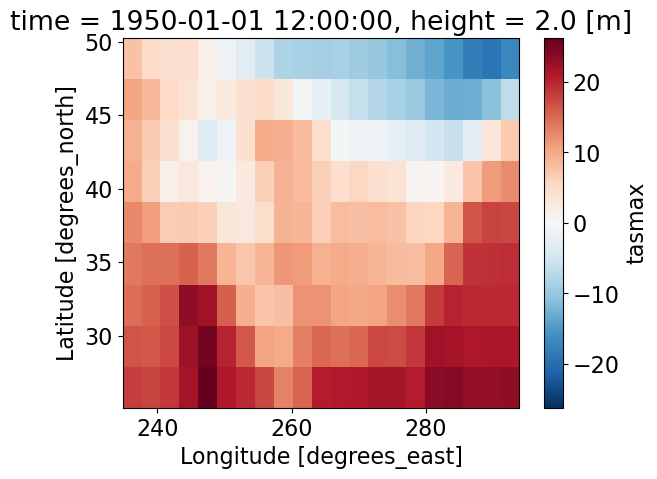

In [5]:
conus_t['heat']['ghg'].tasmax[0].plot()

In [6]:
nc_mask = xr.open_dataset("/global/cfs/cdirs/m3522/cmip6/CMIP6/DAMIP/CCCma/CanESM5/hist-nat/r1i1p1f1/fx/sftlf/gn/v20190429/sftlf_fx_CanESM5_hist-nat_r1i1p1f1_gn.nc")
ocean_mask = nc_mask.sel(
                    lat=slice(bottom, top),              # note: depends on lat ordering
                    lon=slice(left, right),
                    )
ocean_mask_conus = np.ma.masked_equal(ocean_mask.variables["sftlf"], 0)
ocean_mask_conus_tmax = np.broadcast_to(ocean_mask_conus.mask, conus_t["heat"]["all"].tasmax.shape)

In [16]:
# Bring this to full (time, lat, lon) for tasmax in the "all" scenario:
heat_all_da = conus_t["heat"]["all"].tasmax  # DataArray, shape (time, lat, lon)
ocean_mask_conus_tmax = np.broadcast_to(
    ocean_mask_conus.mask, heat_all_da.shape
)  # bool mask, same shape as tasmax

In [20]:
ocean_mask = nc_mask.sel(
    lat=slice(bottom, top),
    lon=slice(left, right),
)

# 2-D land mask: True on land, False on ocean
land_mask_2d = ocean_mask["sftlf"].values > 0

# Example shape reference
heat_ref = conus_t["heat"]["all"].tasmax.values  # (time, lat, lon)

# 3-D ocean mask: True on ocean, False on land
ocean_mask_3d = np.broadcast_to(~land_mask_2d, heat_ref.shape)


# -----------------------------
# 2. Thresholds
# -----------------------------
th = {
    "heat": {"us": {}, "grid": {}, "sep": {}, "comp": {}, "day_sep": {}, "day_comp": {}, "hdays_py": {}},
    "cold": {"us": {}, "grid": {}, "sep": {}, "comp": {}, "day_sep": {}, "day_comp": {}, "hdays_py": {}},
}

for sce in scenarios:
    heat_arr = conus_t["heat"][sce].tasmax.values   # (time, lat, lon)
    cold_arr = conus_t["cold"][sce].tasmin.values   # (time, lat, lon)

    # Convert ocean to NaN for percentile calculations
    heat_land = np.where(ocean_mask_3d, np.nan, heat_arr)
    cold_land = np.where(ocean_mask_3d, np.nan, cold_arr)

    # US-wide thresholds over all CONUS land points
    th["heat"]["us"][sce] = np.nanpercentile(heat_land, 99)
    th["cold"]["us"][sce] = np.nanpercentile(cold_land, 1)

    # Gridpoint thresholds over time
    th_grid_heat = np.nanpercentile(heat_land, 99, axis=0)   # (lat, lon)
    th_grid_cold = np.nanpercentile(cold_land, 1, axis=0)    # (lat, lon)

    # Mask ocean grid points
    th["heat"]["grid"][sce] = np.ma.array(th_grid_heat, mask=~land_mask_2d)
    th["cold"]["grid"][sce] = np.ma.array(th_grid_cold, mask=~land_mask_2d)


# -----------------------------
# 3. Extreme-day boolean arrays
# -----------------------------
for sce in scenarios:
    for ext in temp_ext:
        if ext == "heat":
            arr = conus_t[ext][sce].tasmax.values
            arr_masked = np.ma.array(arr, mask=ocean_mask_3d)

            th[ext]["sep"][sce] = arr_masked >= th[ext]["grid"][sce]
            th[ext]["comp"][sce] = arr_masked >= th[ext]["grid"]["nat"]

        elif ext == "cold":
            arr = conus_t[ext][sce].tasmin.values
            arr_masked = np.ma.array(arr, mask=ocean_mask_3d)

            th[ext]["sep"][sce] = arr_masked <= th[ext]["grid"][sce]
            th[ext]["comp"][sce] = arr_masked <= th[ext]["grid"]["nat"]




/global/homes/b/bharat/anaconda3/envs/pyces/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


NameError: name 'yrs' is not defined

In [23]:
# -----------------------------
# 4. Yearly counts
# -----------------------------
days_per_year = 365
start_year = 1950
yrs = np.array(range(start_year, 2006))
for sce in scenarios:
    for ext in temp_ext:
        count_days_sep = np.zeros((len(yrs), 2))
        count_days_comp = np.zeros((len(yrs), 2))

        # masked array: (year, lat, lon)
        yearly_grid_counts = np.ma.masked_all((len(yrs), land_mask_2d.shape[0], land_mask_2d.shape[1]))

        for idx, yr in enumerate(yrs):
            i0 = idx * days_per_year
            i1 = (idx + 1) * days_per_year

            sep_slice = th[ext]["sep"][sce][i0:i1, :, :]
            comp_slice = th[ext]["comp"][sce][i0:i1, :, :]

            count_days_sep[idx, 0] = yr
            count_days_sep[idx, 1] = np.ma.sum(sep_slice)

            count_days_comp[idx, 0] = yr
            count_days_comp[idx, 1] = np.ma.sum(comp_slice)

            yearly_grid_counts[idx, :, :] = np.ma.sum(comp_slice, axis=0)

        th[ext]["day_sep"][sce] = count_days_sep
        th[ext]["day_comp"][sce] = count_days_comp
        th[ext]["hdays_py"][sce] = yearly_grid_counts

In [21]:
th["heat"]["grid"][sce]

masked_array(
  data=[[--, --, --, 30.968725204467773, 40.78889083862305,
         40.26063537597656, 36.6591682434082, 38.4163932800293,
         40.816734313964844, 41.6389045715332, 30.72835350036621, --, --,
         --, 30.141216278076172, 31.6760311126709, 29.59324836730957, --,
         --, --, --],
        [--, --, --, 36.28233337402344, 50.187923431396484,
         43.37726593017578, 40.0474853515625, 41.729671478271484,
         43.78353500366211, 41.7984619140625, 36.727535247802734,
         33.548095703125, 32.43684768676758, 31.29389190673828,
         32.54892349243164, 34.25764846801758, 29.735698699951172, --,
         --, --, --],
        [--, --, 31.675968170166016, 48.45896530151367,
         50.17311096191406, 43.52815628051758, 42.14492416381836,
         43.70058822631836, 43.53484344482422, 42.22259521484375,
         42.37900924682617, 41.332496643066406, 40.237003326416016,
         38.41314697265625, 37.94145584106445, 35.487937927246094,
         31.36969566

# plot

In [32]:
lats_conus = ocean_mask.lat
lons_conus = ocean_mask.lon
#lats_conus = lats[geo_idx(bottom, lats):geo_idx(top, lats) + 1]
#lons_conus = lons[geo_idx(left, lons):geo_idx(right, lons) + 1]

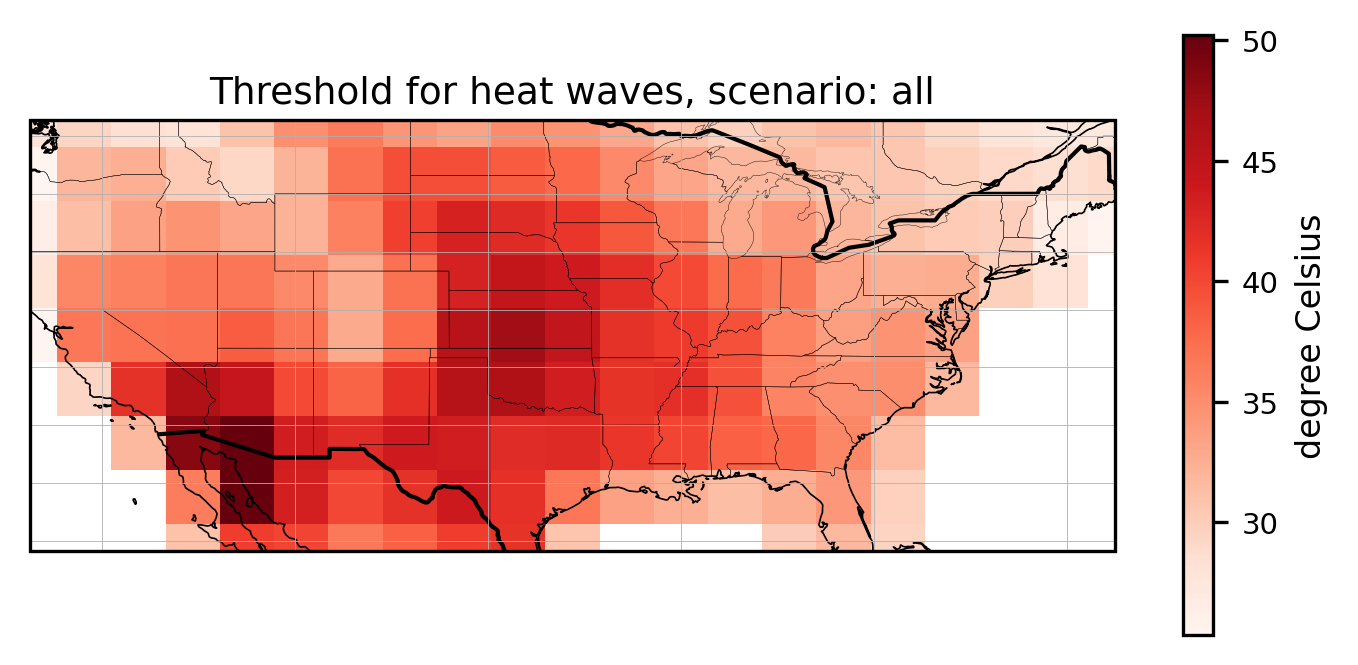

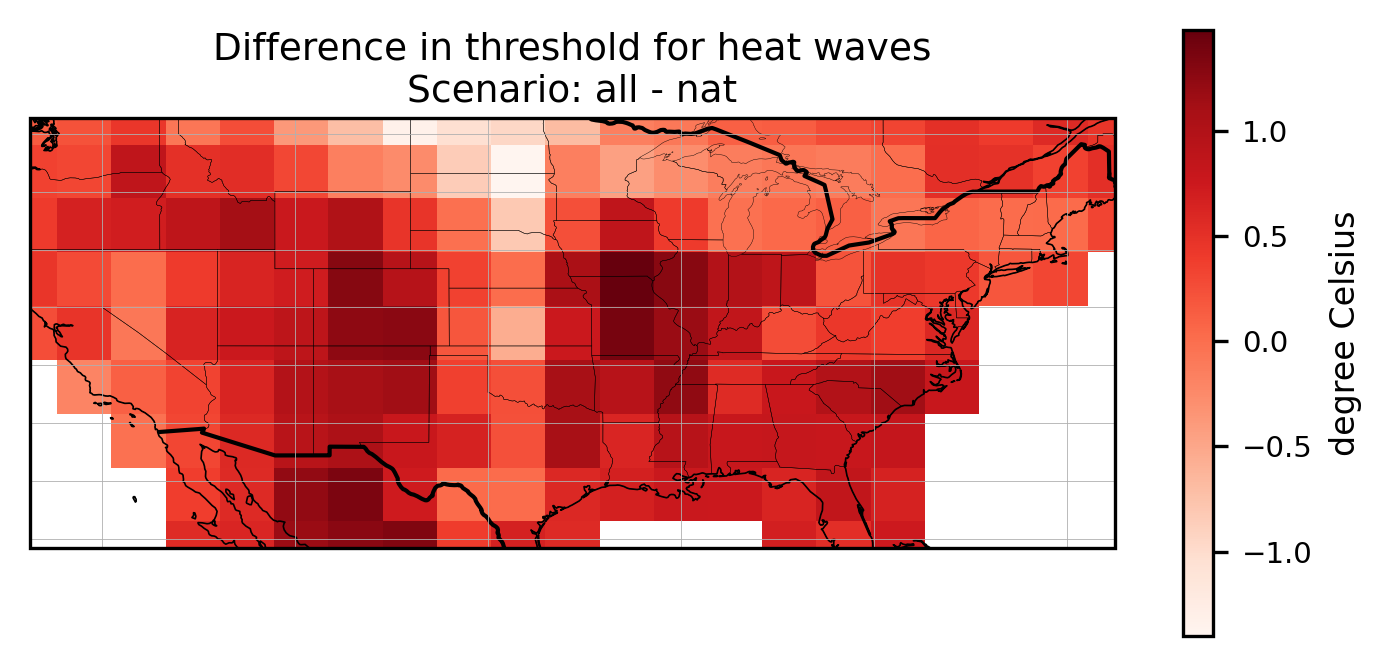

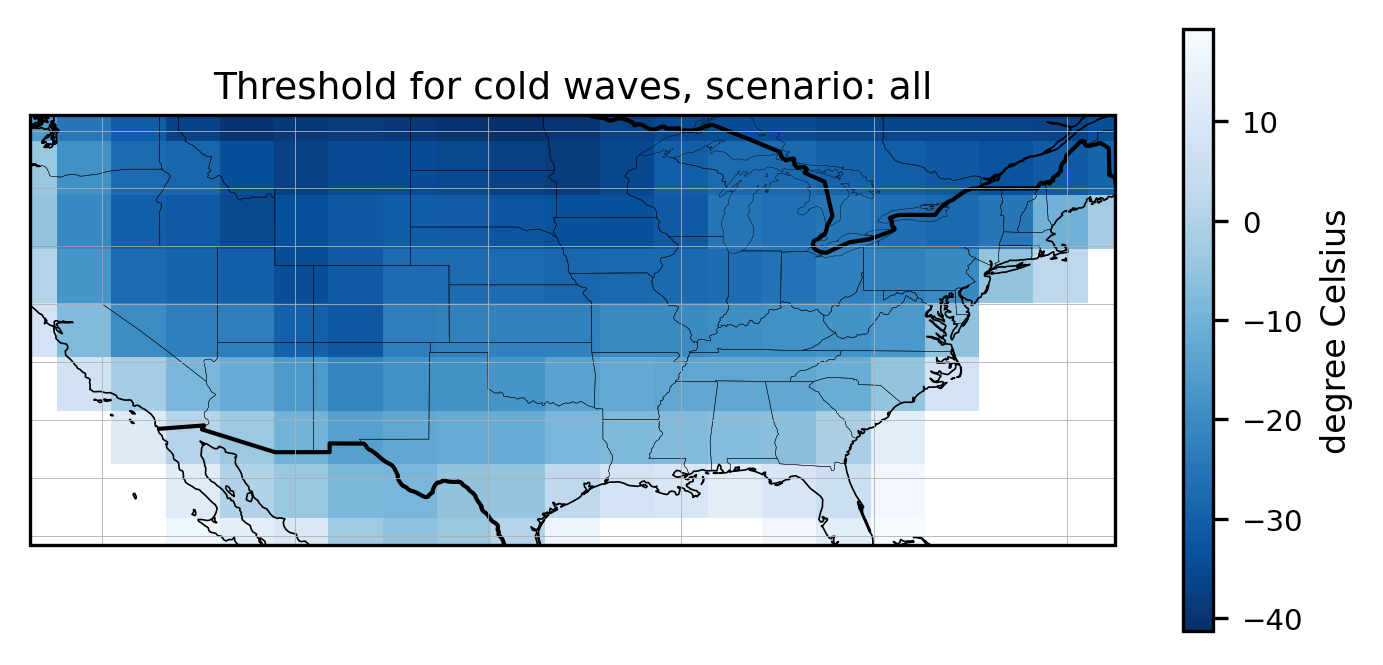

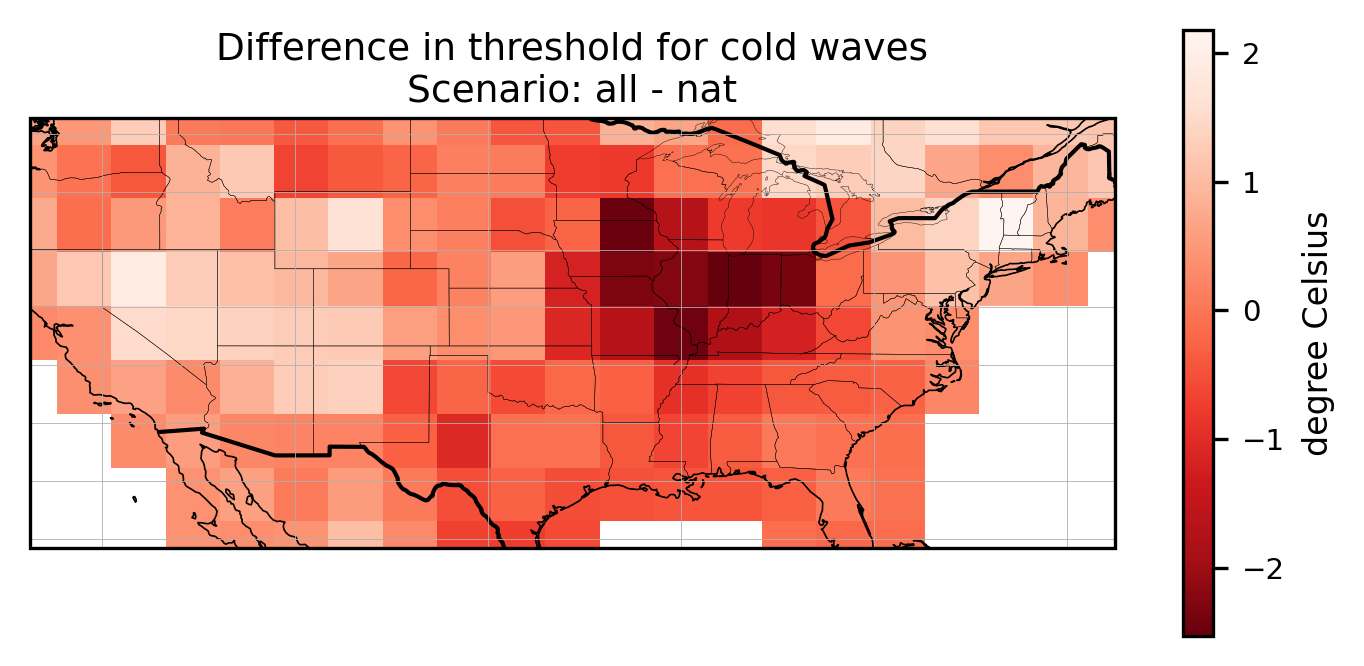

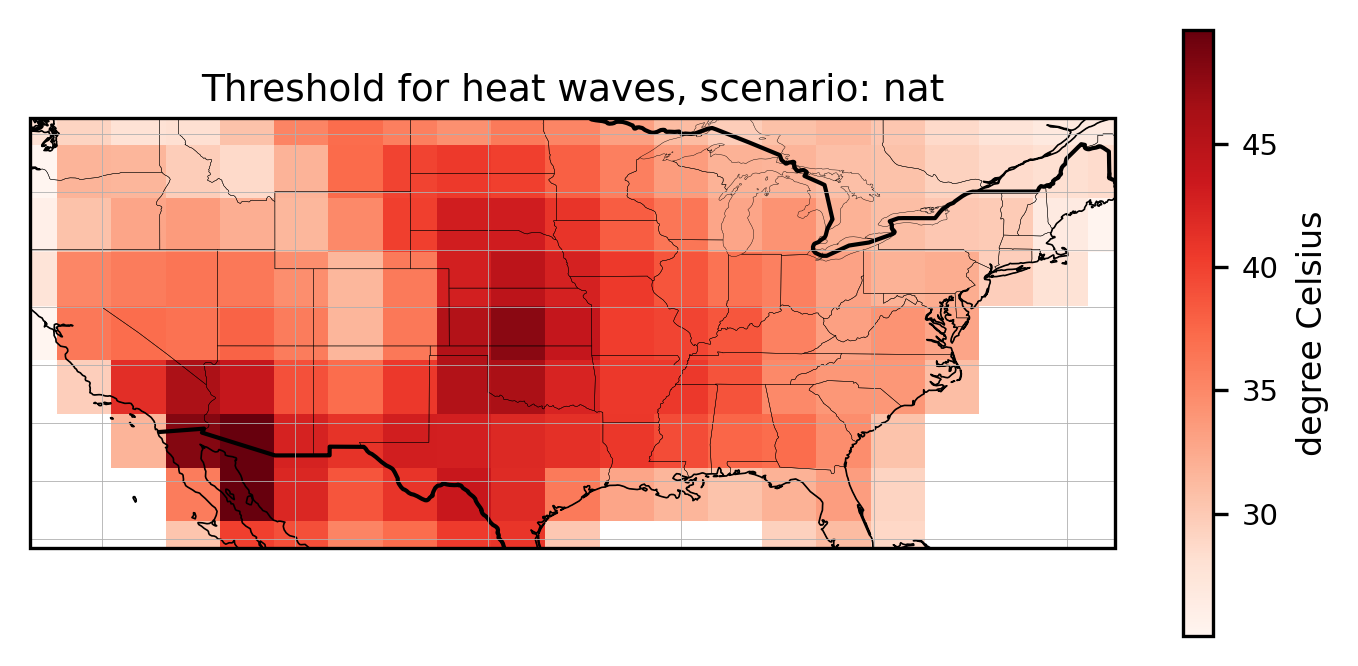

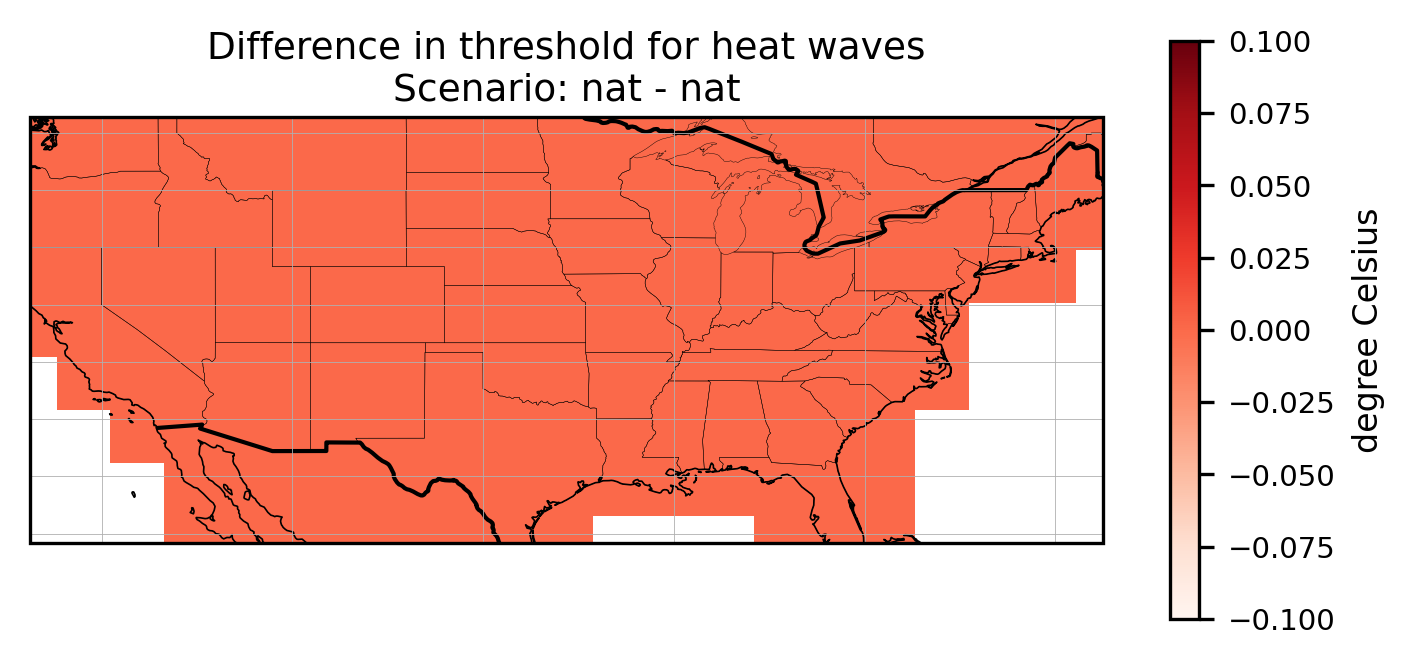

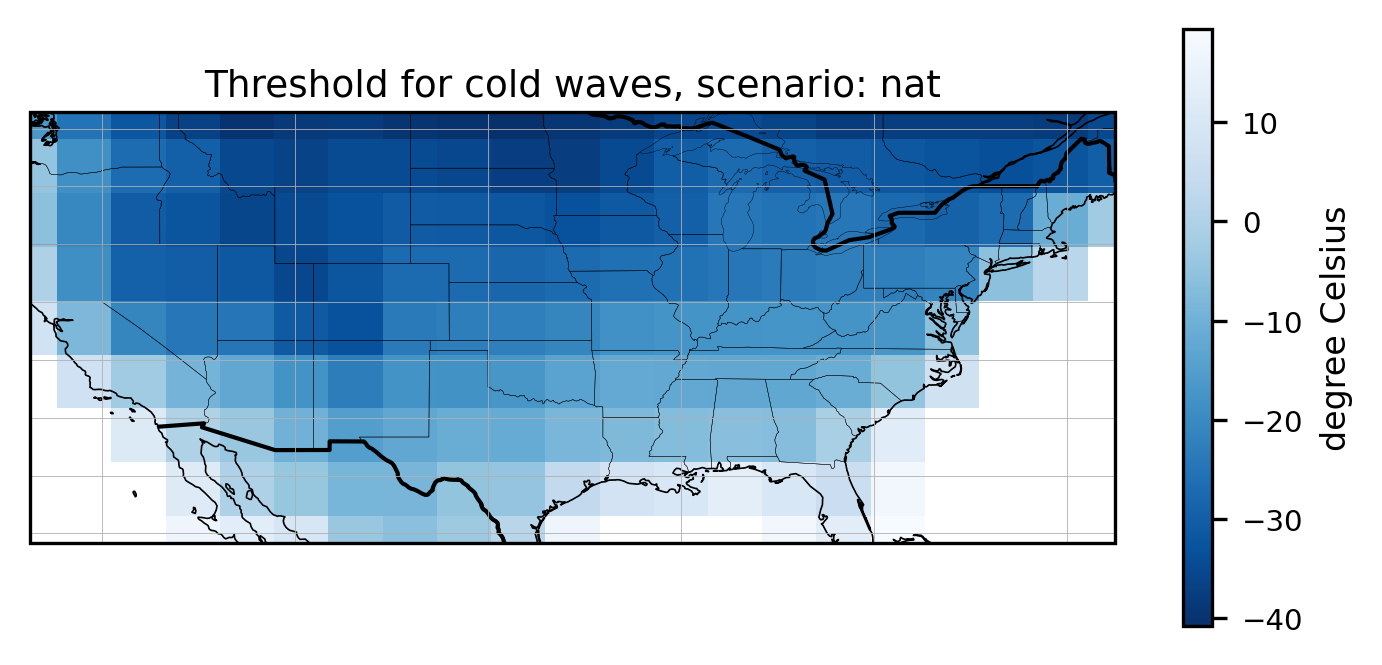

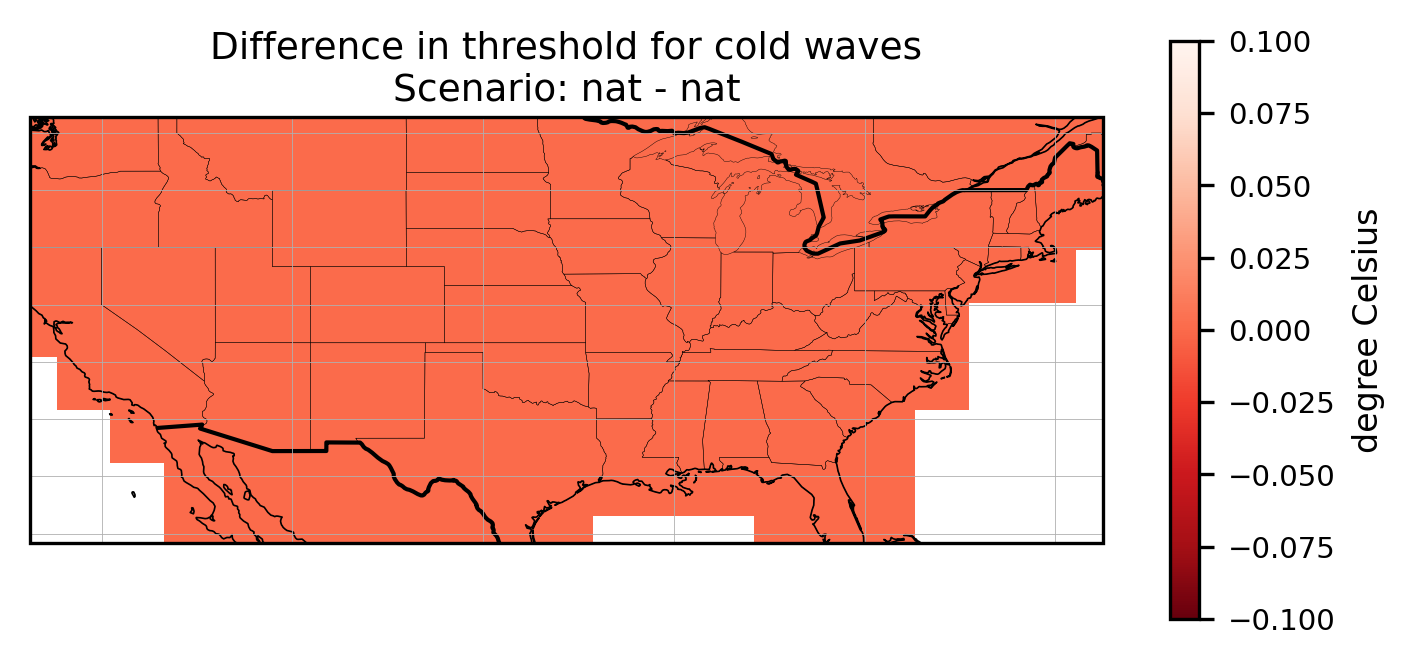

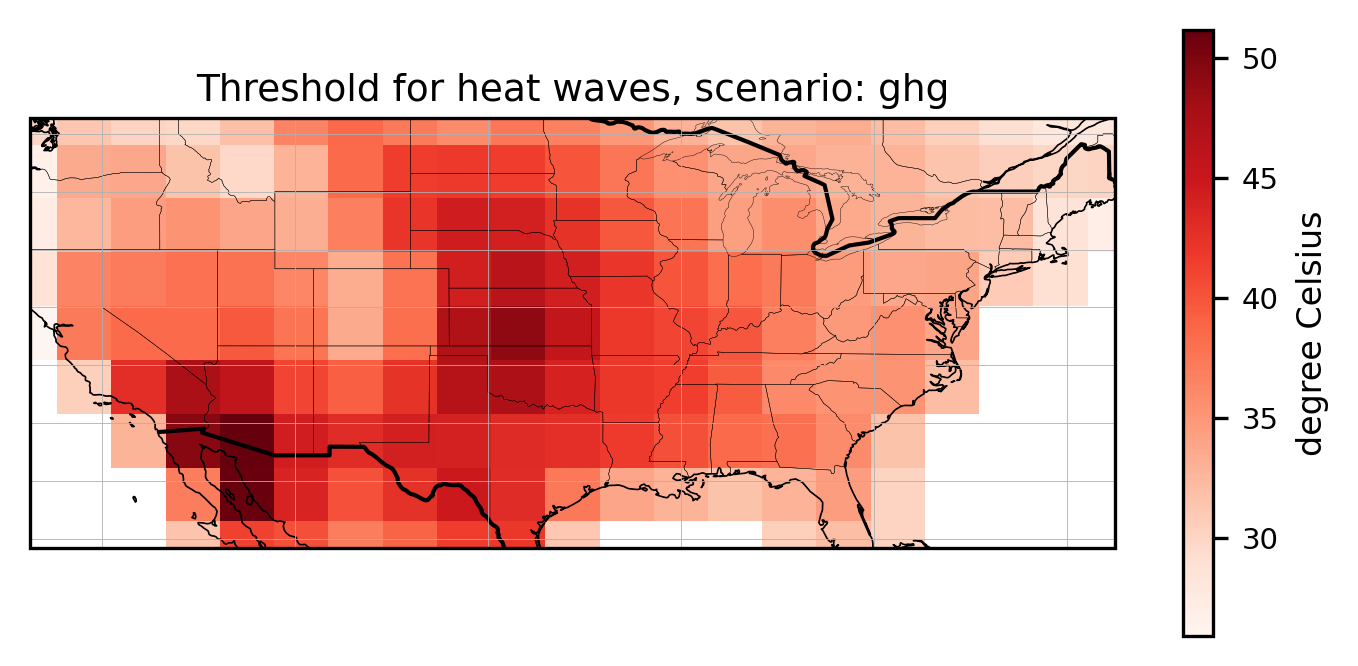

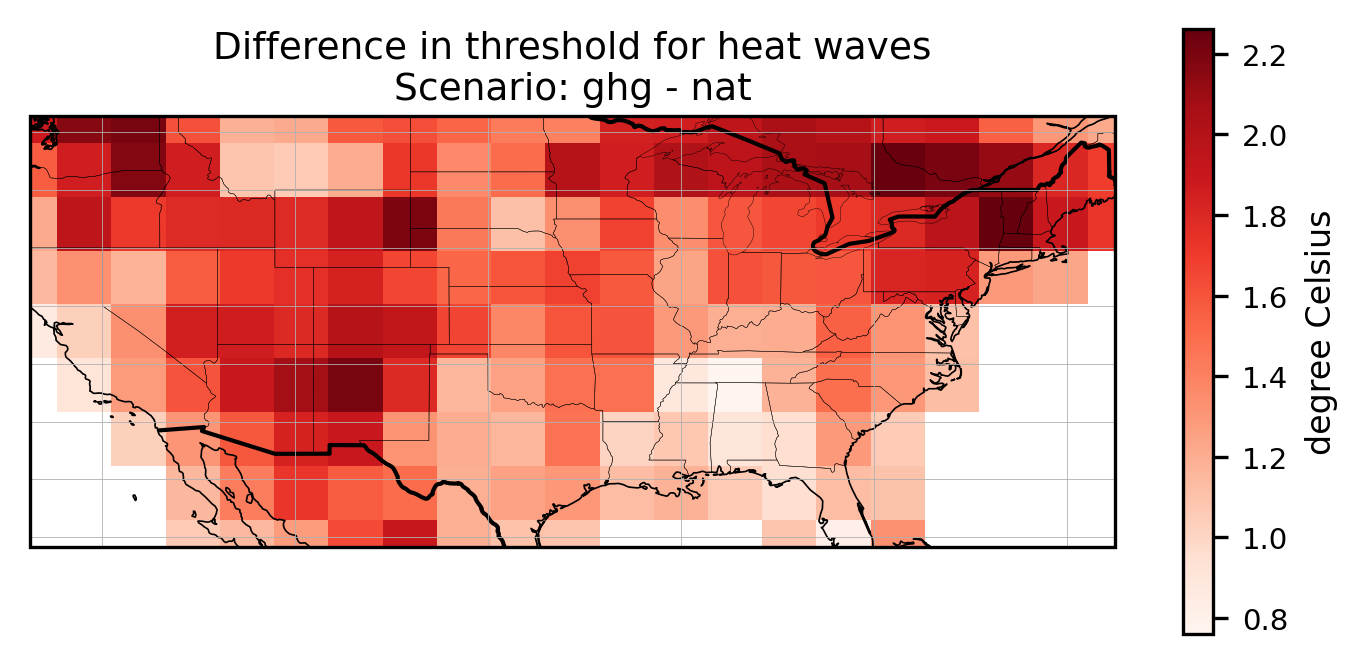

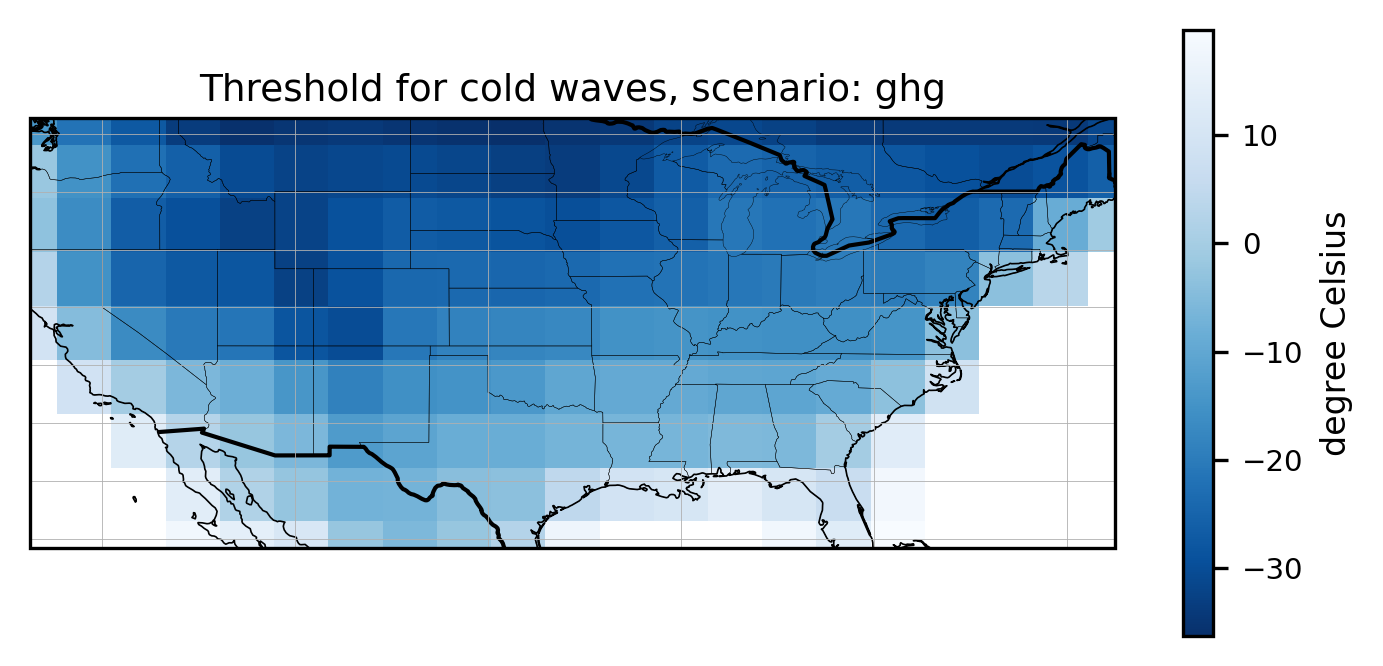

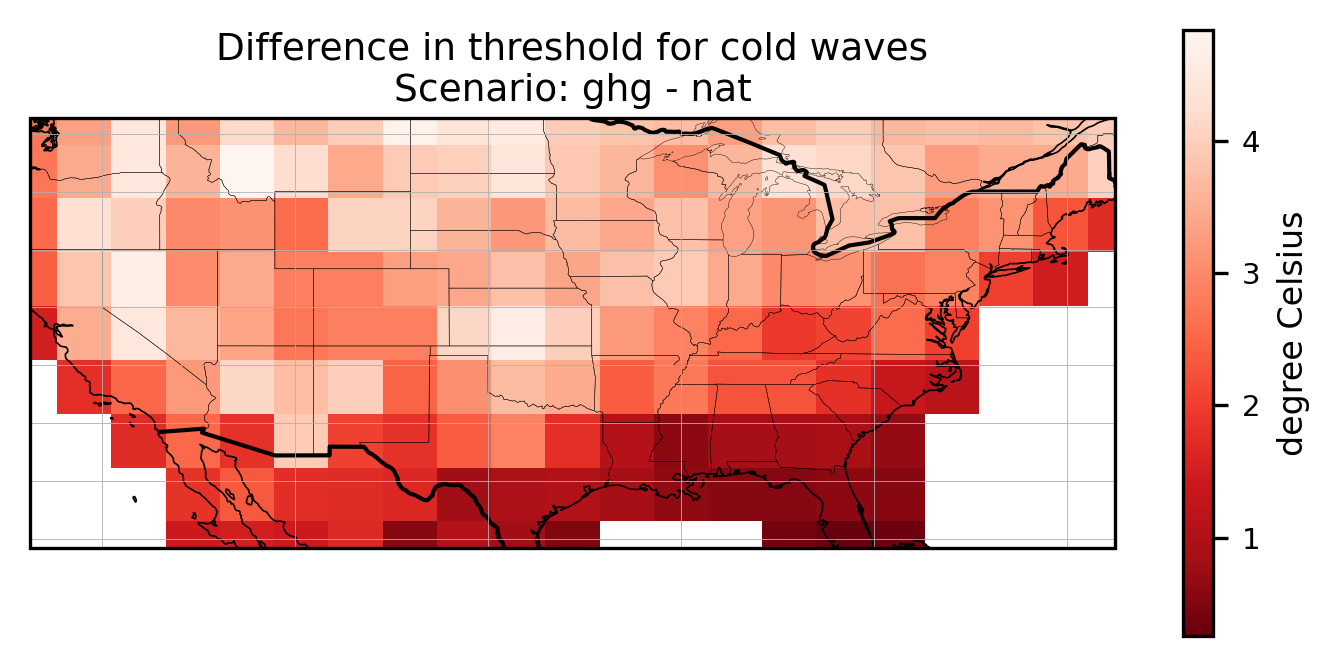

In [45]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl

# Map from 'heat'/'cold' to label and colormaps
EXT_LABEL = {"heat": "heat waves", "cold": "cold waves"}
EXT_CMAP = {"heat": mpl.colormaps["Reds"], "cold": mpl.colormaps["Blues_r"]}
DIFF_CMAP = {"heat": mpl.colormaps["Reds"], "cold": mpl.colormaps["Reds_r"]}

# Smaller fonts to match your example
TITLE_FONTSIZE = 9
CBAR_LABELSIZE = 8
CBAR_TICKSIZE = 7
AX_TICKSIZE = 7

LON, LAT = np.meshgrid(lons_conus, lats_conus)


for sce in scenarios:
    for ext in temp_ext:
        label = EXT_LABEL[ext]

        # --- Threshold map ---
        fig, ax = plt.subplots(
            figsize=(5, 2.5),
            dpi=300,
            tight_layout=True,
            subplot_kw={"projection": ccrs.PlateCarree()},
        )

        mesh = ax.pcolormesh(
            LON,
            LAT,
            th[ext]["grid"][sce],
            transform=ccrs.PlateCarree(),
            cmap=EXT_CMAP[ext],
            shading="nearest",
        )

        ax.coastlines(linewidth=0.4)
        ax.add_feature(cfeature.STATES, linewidth=0.1)
        ax.add_feature(cfeature.BORDERS, linewidth=1.0)
        ax.set_extent(
            [lons_conus[0], lons_conus[-1], lats_conus[0], lats_conus[-1]],
            crs=ccrs.PlateCarree(),
        )
        gl = ax.gridlines(draw_labels=False, linewidth=0.2)

        ax.tick_params(labelsize=AX_TICKSIZE)

        cbar = plt.colorbar(mesh, ax=ax)
        cbar.ax.set_ylabel("degree Celsius", fontsize=CBAR_LABELSIZE)
        cbar.ax.tick_params(labelsize=CBAR_TICKSIZE)

        ax.set_title(
            f"Threshold for {label}, scenario: {sce}",
            fontsize=TITLE_FONTSIZE,
            pad=4,
        )

        fname = os.path.join(out_path, f"th_{ext}_{sce}.png")
        fig.savefig(fname, bbox_inches="tight")
        # plt.close(fig)

        # --- Difference map (scenario minus nat) ---
        fig, ax = plt.subplots(
            figsize=(5, 2.5),
            dpi=300,
            tight_layout=True,
            subplot_kw={"projection": ccrs.PlateCarree()},
        )

        diff = th[ext]["grid"][sce] - th[ext]["grid"]["nat"]

        mesh = ax.pcolormesh(
            LON,
            LAT,
            diff,
            transform=ccrs.PlateCarree(),
            cmap=DIFF_CMAP[ext],
            shading="nearest",
        )

        ax.coastlines(linewidth=0.4)
        ax.add_feature(cfeature.STATES, linewidth=0.1)
        ax.add_feature(cfeature.BORDERS, linewidth=1.0)
        ax.set_extent(
            [lons_conus[0], lons_conus[-1], lats_conus[0], lats_conus[-1]],
            crs=ccrs.PlateCarree(),
        )
        gl = ax.gridlines(draw_labels=False, linewidth=0.2)

        ax.tick_params(labelsize=AX_TICKSIZE)

        cbar = plt.colorbar(mesh, ax=ax)
        cbar.ax.set_ylabel("degree Celsius", fontsize=CBAR_LABELSIZE)
        cbar.ax.tick_params(labelsize=CBAR_TICKSIZE)

        ax.set_title(
            f"Difference in threshold for {label}\nScenario: {sce} - nat",
            fontsize=TITLE_FONTSIZE,
            pad=4,
        )

        fname = os.path.join(out_path, f"th_diff_{ext}_{sce}-nat.png")
        fig.savefig(fname, bbox_inches="tight")
        # plt.close(fig)

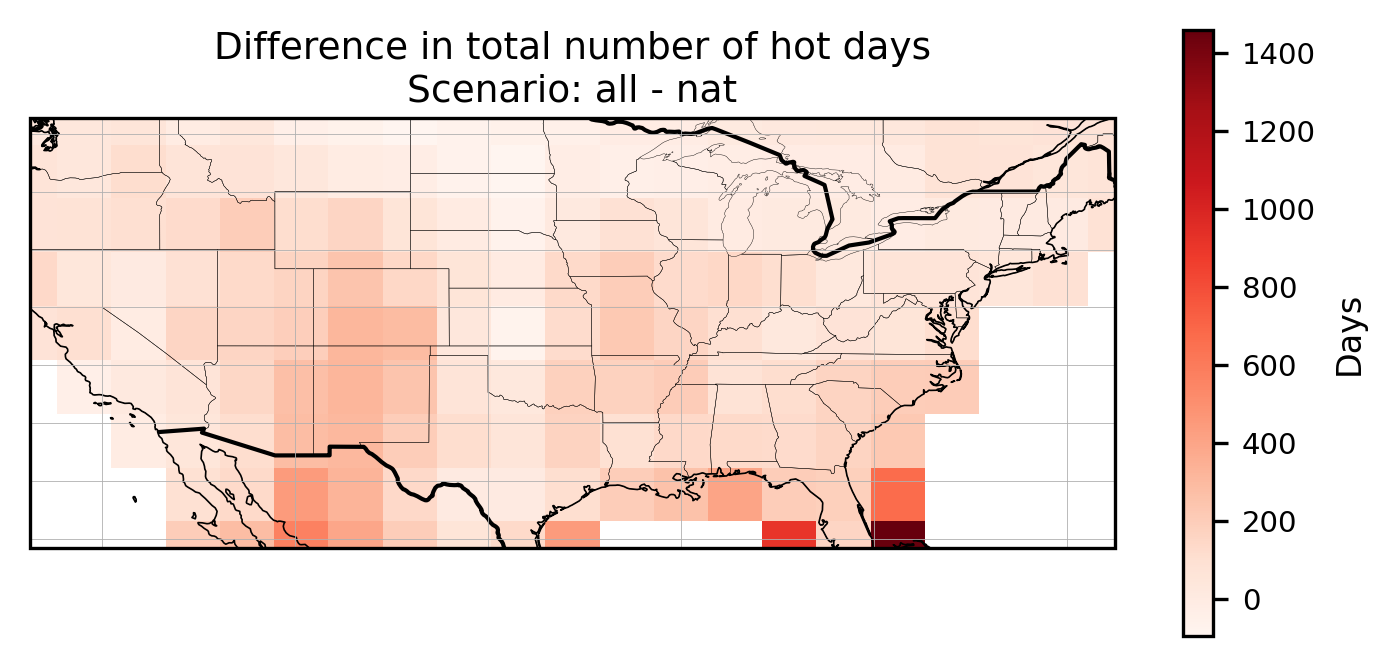

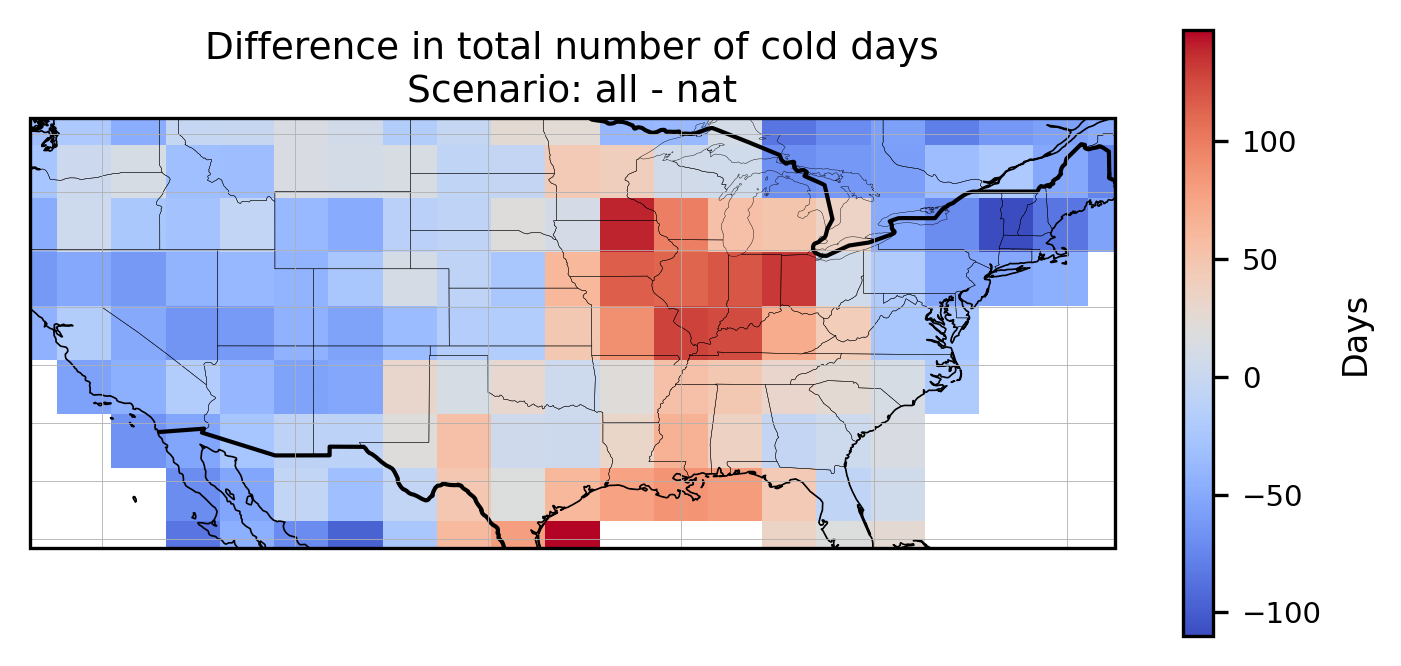

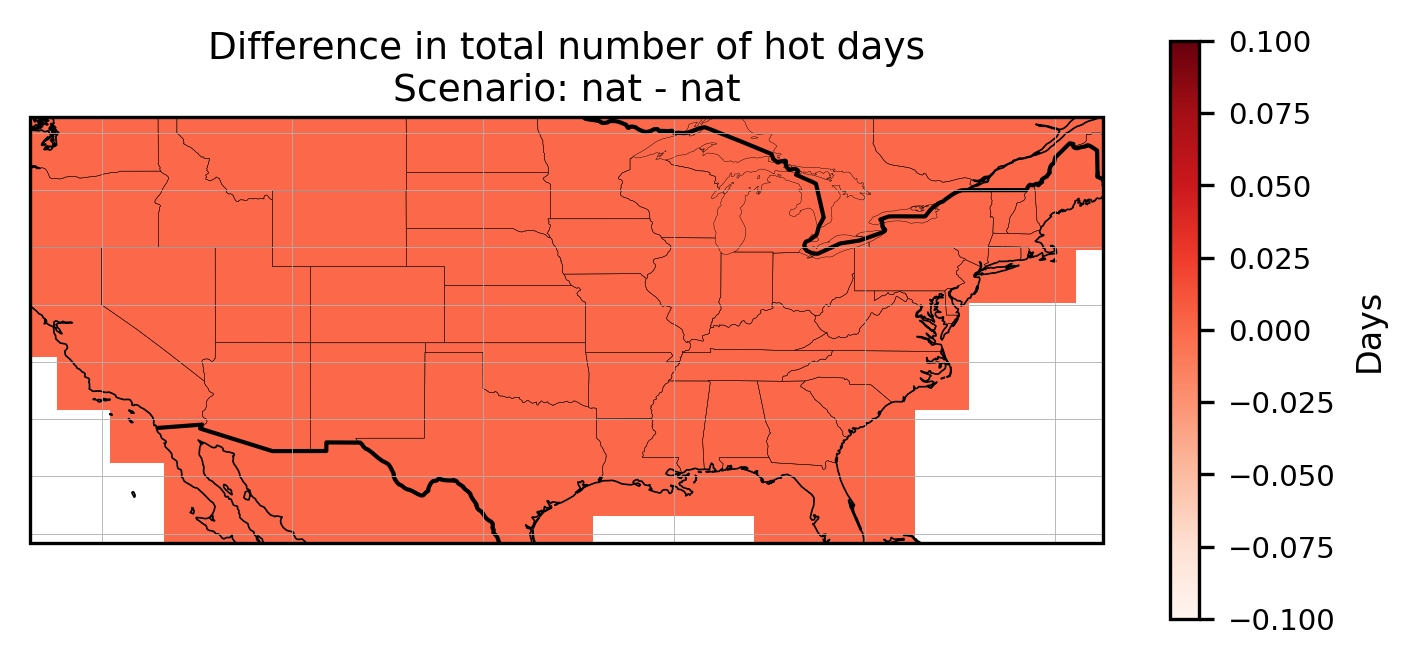

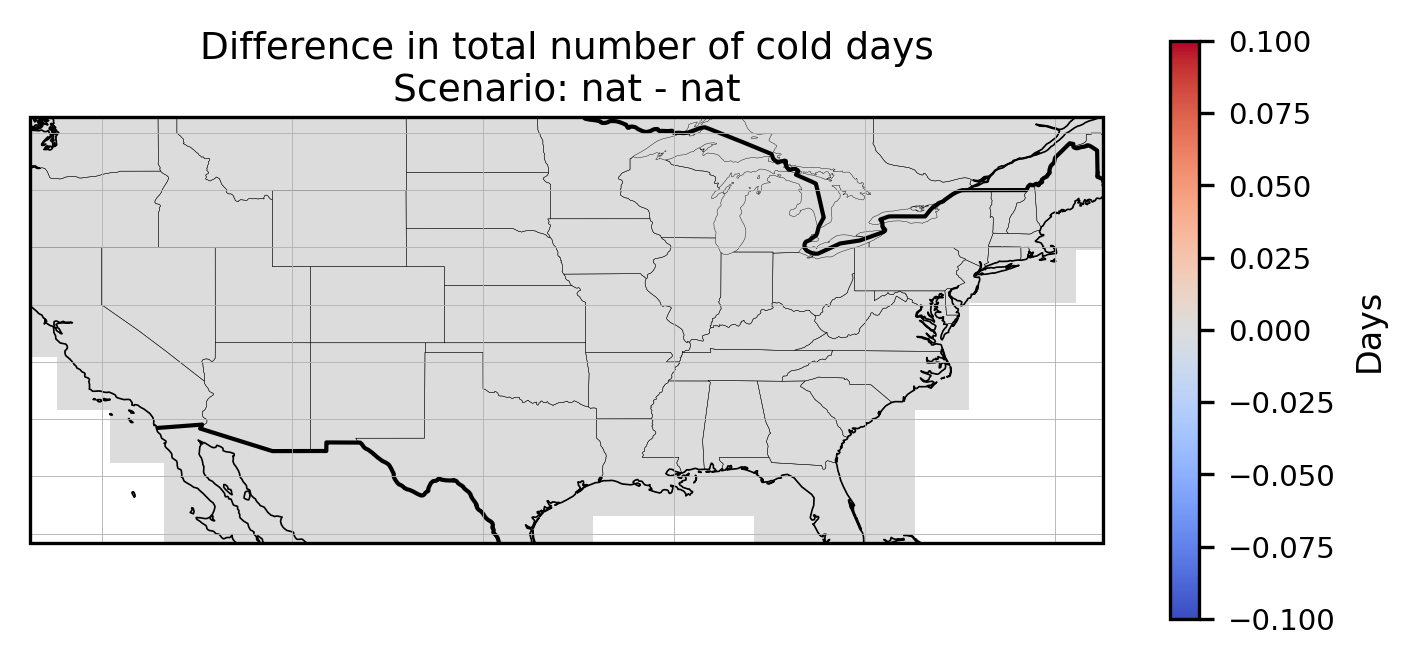

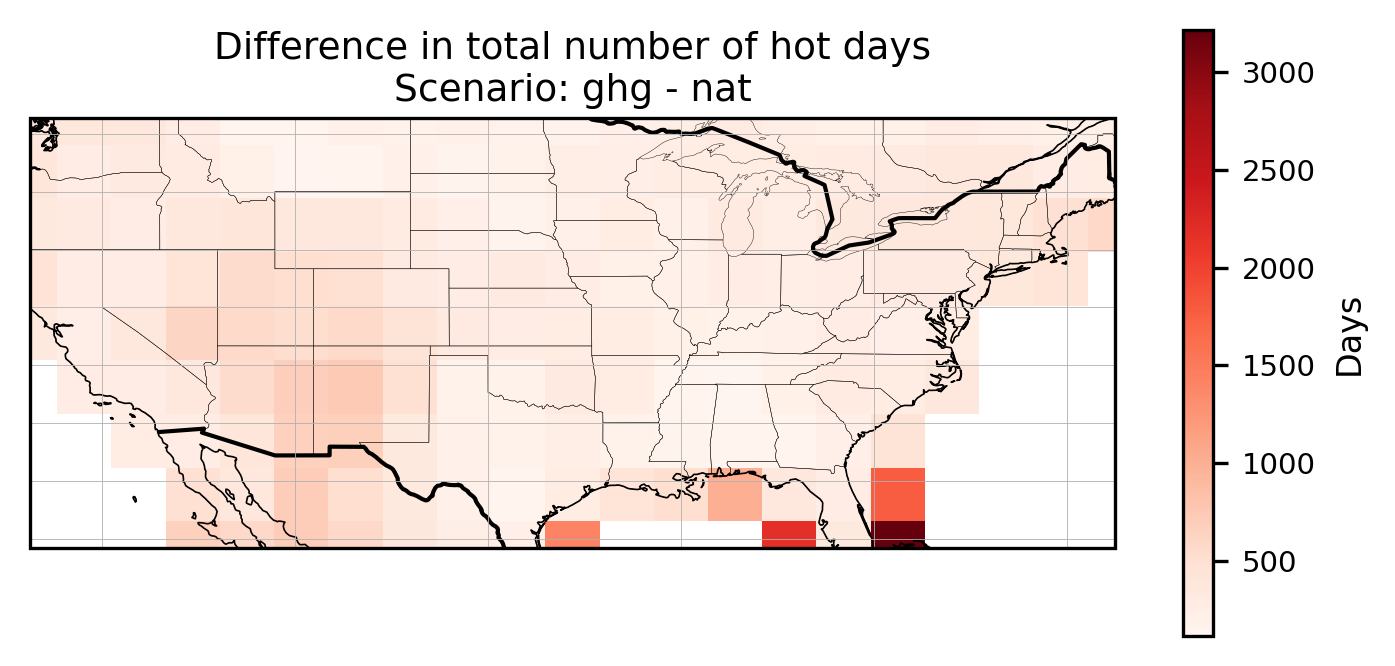

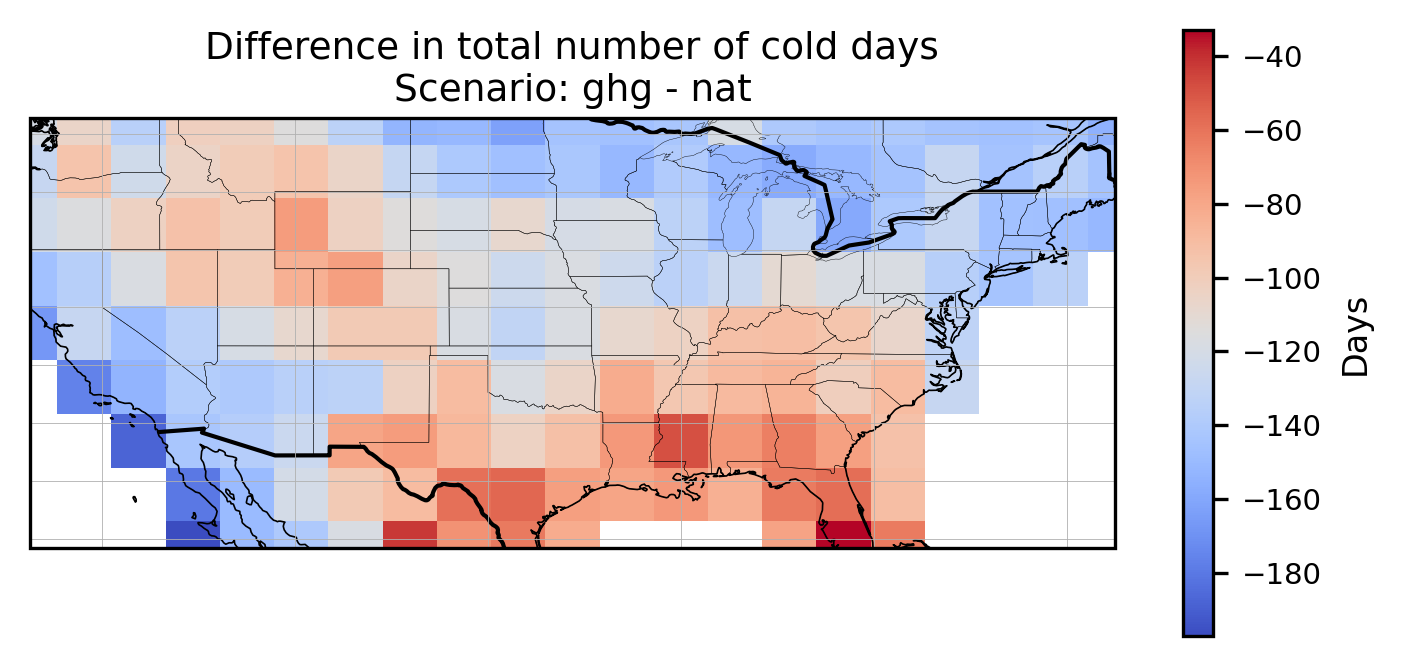

In [47]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl

EXT_LABEL = {"heat": "hot", "cold": "cold"}
EXT_CMAP_TOTAL_DIFF = {
    "heat": mpl.colormaps["Reds"],
    "cold": mpl.colormaps["coolwarm"],
}

# Font sizes to match your example style
TITLE_FONTSIZE = 9     # try 8 if you want even smaller
CBAR_LABELSIZE = 8
CBAR_TICKSIZE = 7
AX_TICKSIZE = 7

LON, LAT = np.meshgrid(lons_conus, lats_conus)

# Spatial map of total increase in hot/cold days (scenario vs nat)
for sce in scenarios:
    for ext in temp_ext:
        label = EXT_LABEL[ext]

        # Sum over years → total days per grid cell
        total_sce = np.sum(th[ext]["hdays_py"][sce], axis=0)     # (lat, lon)
        total_nat = np.sum(th[ext]["hdays_py"]["nat"], axis=0)   # (lat, lon)
        diff_days = total_sce - total_nat

        fig, ax = plt.subplots(
            figsize=(5, 2.5),
            dpi=300,
            tight_layout=True,
            subplot_kw={"projection": ccrs.PlateCarree()},
        )

        mesh = ax.pcolormesh(
            LON,
            LAT,
            diff_days,
            transform=ccrs.PlateCarree(),
            cmap=EXT_CMAP_TOTAL_DIFF[ext],
            shading="nearest",
        )

        ax.coastlines(linewidth=0.4)
        ax.add_feature(cfeature.STATES, linewidth=0.1)
        ax.add_feature(cfeature.BORDERS, linewidth=1.0)
        ax.set_extent(
            [lons_conus[0], lons_conus[-1], lats_conus[0], lats_conus[-1]],
            crs=ccrs.PlateCarree(),
        )
        ax.gridlines(draw_labels=False, linewidth=0.2)

        # Axis ticks
        ax.tick_params(labelsize=AX_TICKSIZE)

        # Colorbar
        cbar = plt.colorbar(mesh, ax=ax)
        cbar.ax.set_ylabel("Days", fontsize=CBAR_LABELSIZE)
        cbar.ax.tick_params(labelsize=CBAR_TICKSIZE)

        # Title
        ax.set_title(
            f"Difference in total number of {label} days\nScenario: {sce} - nat",
            fontsize=TITLE_FONTSIZE,
            pad=4,
        )

        fname = os.path.join(out_path, f"diff_{ext}_days_{sce}-nat.png")
        fig.savefig(fname, bbox_inches="tight")
        # plt.close(fig)

In [48]:
pwd

'/global/u2/b/bharat/repos/hwconus'

In [49]:
ls /global/u2/b/bharat/repos/hwconus/plots

diff_cold_days_all-nat.png  th_cold_all.png           th_diff_heat_all-nat.png
diff_cold_days_ghg-nat.png  th_cold_ghg.png           th_diff_heat_ghg-nat.png
diff_cold_days_nat-nat.png  th_cold_nat.png           th_diff_heat_nat-nat.png
diff_heat_days_all-nat.png  th_diff_cold_all-nat.png  th_heat_all.png
diff_heat_days_ghg-nat.png  th_diff_cold_ghg-nat.png  th_heat_ghg.png
diff_heat_days_nat-nat.png  th_diff_cold_nat-nat.png  th_heat_nat.png
